# 1D CNN for Heart Rate Interval Segmentation

**Master's Thesis Implementation**

This notebook implements a 1D Convolutional Neural Network for detecting workout interval boundaries from heart rate data.

Run all cells from top to bottom.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# TensorFlow imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')


from multi_channel_cnn import (
    MultiChannelConfig,
    create_hr_features_grouped,
    prepare_multichannel_segments,
    train_multichannel_cnn,
    predict_multichannel_cnn
)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Reproducibility
RANDOM_SEED = 123
import random  # ADD THIS LINE
random.seed(RANDOM_SEED)  # ADD THIS LINE
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)  # ADD THIS LINE

print(f"✓ Imports complete")
print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ Random seed: {RANDOM_SEED}")

✓ Imports complete
✓ TensorFlow version: 2.20.0
✓ Random seed: 123


## 2. Configuration

In [2]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    short_window: int = 30
    medium_window: int = 60
    long_window: int = 120
    
    # CNN specific
    segment_length: int = 300  # 5 minutes
    segment_overlap: int = 150  # 50% overlap
    
    # Post-processing
    peak_distance: int = 30
    peak_prominence: float = 0.1
    smooth_sigma: float = 5.0

# Single config for helper functions (peak detection, evaluation)
CONFIG = Config()

# Multi-channel CNN config (extends base config with feature groups)
CONFIG_MC = MultiChannelConfig(
    random_seed=123,
    short_window=30,
    medium_window=60,
    long_window=120,
    segment_length=300,
    segment_overlap=150,
    peak_distance=30,
    peak_prominence=0.1,
    smooth_sigma=5.0
)

print(f"✓ Configuration set")
print(f"✓ Multi-channel CNN: {len(CONFIG_MC.feature_groups)} feature groups")
for group_name in CONFIG_MC.feature_groups.keys():
    print(f"    • {group_name}")

✓ Configuration set
✓ Multi-channel CNN: 5 feature groups
    • raw_and_smooth
    • trends
    • baseline_deviations
    • rolling_stats
    • temporal_context


## 3. Your Data Configuration

In [3]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all",
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2']
  Test sessions: 11


## 4. Helper Functions

Feature engineering, post-processing, and evaluation functions.

In [4]:
def create_hr_features(df: pd.DataFrame, config: Config) -> pd.DataFrame:
    """Create rich feature set from heart rate time series."""
    features = pd.DataFrame(index=df.index)
    hr = df['heart_rate'].values
    
    # Smoothed HR
    features['hr_raw'] = hr
    features['hr_smooth_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).mean()
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()
    
    # Derivatives
    features['hr_diff_1s'] = df['heart_rate'].diff(1)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)
    features['hr_accel'] = features['hr_diff_1s'].diff(1)
    
    # Rolling statistics
    features['hr_std_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).std()
    features['hr_min_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).min()
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()
    features['hr_range_short'] = features['hr_max_short'] - features['hr_min_short']
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    
    # Relative features
    features['hr_vs_short_baseline'] = hr - features['hr_smooth_short']
    features['hr_vs_medium_baseline'] = hr - features['hr_smooth_medium']
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']
    
    # Trends
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)
    features['hr_decreasing'] = (features['hr_diff_10s'] < 0).astype(int)
    features['hr_stable'] = (features['hr_diff_10s'].abs() < 1).astype(int)
    
    # Lagged
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_60s'] = df['heart_rate'].shift(60)
    features['hr_lag_90s'] = df['heart_rate'].shift(90)
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - features['hr_lag_60s']
    
    # Clean
    features = features.replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0)
    for col in features.columns:
        if features[col].std() > 0:
            q99, q01 = features[col].quantile(0.99), features[col].quantile(0.01)
            features[col] = features[col].clip(q01, q99)
    return features


def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks with interval count constraint."""
    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)
    forced_peaks, n_remaining = [0], n_expected_intervals - 1
    peaks, _ = find_peaks(probs_smooth[config.peak_distance:], distance=config.peak_distance, prominence=config.peak_prominence)
    peaks = peaks + config.peak_distance
    if len(peaks) >= n_remaining:
        peak_heights = probs_smooth[peaks]
        peaks = peaks[np.argsort(peak_heights)[-n_remaining:]]
    return np.sort(np.concatenate([forced_peaks, peaks]))


def evaluate_with_tolerance_asymmetric(y_true, y_pred, tolerance_before=3, tolerance_after=7):
    """Evaluate with asymmetric tolerance."""
    true_b, pred_b = np.where(y_true == 1)[0], np.where(y_pred == 1)[0]
    matched_p = sum(1 for p in pred_b if any(-tolerance_before <= p - t <= tolerance_after for t in true_b))
    matched_t = sum(1 for t in true_b if any(-tolerance_before <= p - t <= tolerance_after for p in pred_b))
    precision = matched_p / len(pred_b) if len(pred_b) > 0 else 0
    recall = matched_t / len(true_b) if len(true_b) > 0 else 0
    f_beta = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) > 0 else 0
    errors = [np.abs(true_b - p).min() for p in pred_b]
    return {'precision': precision, 'recall': recall, 'f_beta': f_beta, 'n_true': len(true_b), 
            'n_pred': len(pred_b), 'mean_error_sec': np.mean(errors) if errors else 0}

print("✓ Helper functions defined")

✓ Helper functions defined


## 5. Load Data

In [5]:
def load_all_sessions(athletes):
    session_data = {}
    for athlete, meta in athletes.items():
        label_dir, allowed = meta["label_dir"], meta["allowed_files"]
        csv_files = sorted([f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")] 
                          if allowed == "all" else [f.replace(".fit", "_with_manual_labels.csv") for f in allowed])
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path): continue
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                df['heart_rate'] = df['heart_rate'].ffill().bfill()
                if 'power' in df.columns: df['power'] = df['power'].ffill().bfill().fillna(0)
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e: print(f"❌ {filename}: {e}")
    return session_data

print("\n📂 Loading sessions...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions")


📂 Loading sessions...
✓ Athlete12 - 10536403349_5006_row
✓ Athlete12 - 10543962115_10006_row
✓ Athlete12 - 10551999765_10006_row
✓ Athlete12 - 10652950510_Btchen_fahren
✓ Athlete12 - 10674304801_Btchen_fahren_in_Etappen_3
✓ Athlete12 - 10694767945_Btchen_fahren_
✓ Athlete12 - 10809067165_3007_row
✓ Athlete12 - 11636429453_4558_row
✓ Athlete12 - 11783093951_4x2000_sub8
✓ Athlete12 - 11791568584_
✓ Athlete12 - 11808467517_
✓ Athlete12 - 11838948742_3006_row
✓ Athlete12 - 11846980624_Platt_
✓ Athlete12 - 11855866225_In_den_Seilen
✓ Athlete12 - 11864381887_Catwalk_
✓ Athlete12 - 11912062341_500er_in_grau
✓ Athlete12 - 11962243206_Wundmanagement
✓ Athlete12 - 11971395278_Use_it_or_lose_it
✓ Athlete12 - 11987690514_Besser_als_Nix
✓ Athlete12 - 11994450315_Airobics
✓ Athlete12 - 12036692734_Exhausted
✓ Athlete12 - 12069656901_Schwitzen_im_Sitzen
✓ Athlete12 - 12501679452_Zustand_nach_Xtem_Atemwegsin
✓ Athlete12 - 12806981726_Row_Stretch__Stabi
✓ Athlete12 - 12846436186_Synchronflug
✓ Athlete

## 6. Prepare Features and Split Data

In [6]:
train_sessions, test_sessions_data = [], []
for (athlete, session), df in hr_session_data.items():
    # Use new grouped feature creation
    features_df, grouped_features = create_hr_features_grouped(df, CONFIG_MC)
    X, y = features_df.values, df['manual_timestamp_numerical'].values
    if np.any(np.isnan(X)) or np.any(np.isinf(X)): continue

    session_info = {
        'athlete': athlete,
        'session': session,
        'X': X,  # Keep this for backward compatibility
        'y': y,
        'n_intervals': y.sum(),
        'duration_sec': len(y),
        'feature_names': features_df.columns.tolist(),
        'df': df,
        'grouped_features': grouped_features  # NEW: Store grouped features
    }
    (test_sessions_data if (athlete, session) in test_sessions else train_sessions).append(session_info)

# Scaling (same as before)
scaler = StandardScaler().fit(np.vstack([s['X'] for s in train_sessions]))
for s in train_sessions + test_sessions_data: s['X'] = scaler.transform(s['X'])

print(f"✓ Train: {len(train_sessions)}, Test: {len(test_sessions_data)}, Features: {train_sessions[0]['X'].shape[1]}")
print(f"✓ Grouped features stored in each session")

✓ Train: 60, Test: 11, Features: 28
✓ Grouped features stored in each session


## 7. Prepare CNN Segments

In [7]:
def prepare_cnn_segments(sessions, seg_len=300, overlap=150):
    all_X, all_y, stride = [], [], seg_len - overlap
    for s in sessions:
        for i in range((len(s['X']) - seg_len) // stride + 1):
            start, end = i * stride, i * stride + seg_len
            if end <= len(s['X']): all_X.append(s['X'][start:end]); all_y.append(s['y'][start:end])
    return np.array(all_X), np.array(all_y)

# Prepare multi-channel segments
print("Preparing multi-channel segments...")
X_train_mc, y_train_mc = prepare_multichannel_segments(train_sessions, CONFIG_MC)

print(f"\n✓ Multi-channel training data:")
for group_name, X_group in X_train_mc.items():
    print(f"  {group_name:25s}: {X_group.shape}")
print(f"  Labels: {y_train_mc.shape}")
print(f"  Positive: {y_train_mc.sum():,}/{y_train_mc.size:,} ({y_train_mc.sum()/y_train_mc.size*100:.3f}%)")

Preparing multi-channel segments...

✓ Multi-channel training data:
  raw_and_smooth           : (1165, 300, 4)
  trends                   : (1165, 300, 8)
  baseline_deviations      : (1165, 300, 3)
  rolling_stats            : (1165, 300, 7)
  temporal_context         : (1165, 300, 6)
  Labels: (1165, 300)
  Positive: 1,139/349,500 (0.326%)


## 8. Build and Train 1D CNN

In [8]:
print("\n🏋️ Training multi-channel CNN...")
model_mc, history_mc = train_multichannel_cnn(X_train_mc, y_train_mc, CONFIG_MC)
print("✓ Multi-channel CNN trained!")


🏋️ Training multi-channel CNN...
Positive weight: 305.85

Input shapes per group:
  raw_and_smooth           : (300, 4)
  trends                   : (300, 8)
  baseline_deviations      : (300, 3)
  rolling_stats            : (300, 7)
  temporal_context         : (300, 6)

📊 Model summary:
Total parameters: 856,273

🏋️ Training multi-channel CNN...
Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 33s 476ms/step - accuracy: 0.6325 - loss: 1.1828 - learning_rate: 0.0010
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 464ms/step - accuracy: 0.7751 - loss: 0.9117 - learning_rate: 0.0010
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 501ms/step - accuracy: 0.8097 - loss: 0.8548 - learning_rate: 0.0010
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 477ms/step - accuracy: 0.8132 - loss: 0.7834 - learning_rate: 0.0010
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 455ms/step - accuracy: 0.8221 - loss: 0.7298 - learning_rate: 0.0010
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 504ms/step - accuracy: 0.8325 - loss: 0.7206 - learn

KeyError: 'val_loss'

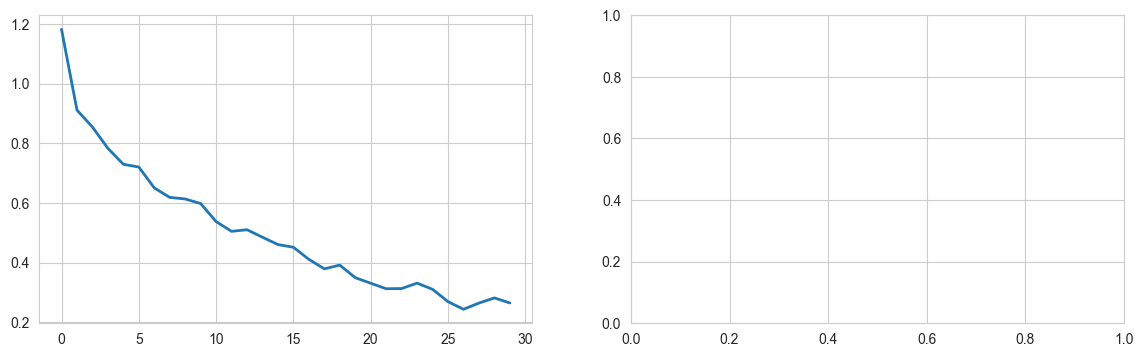

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_mc.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_mc.history['val_loss'], label='Val Loss', linewidth=2, color='red')
axes[0].axhline(y=3, color='orange', linestyle='--', label='Trouble Zone')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss (OVERFITTING!)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_mc.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history_mc.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluate on Test Sessions

In [11]:
print("\n📊 Evaluating on test sessions...")
results_mc = []

for s in test_sessions_data:
    # Use multi-channel prediction
    proba = predict_multichannel_cnn(model_mc, s, CONFIG_MC)

    # Peak detection (same as before)
    peaks = detect_peaks_with_constraint(proba, s['n_intervals'], CONFIG)
    pred = np.zeros(len(proba), dtype=int)
    pred[peaks] = 1

    # Evaluation (same as before)
    m = evaluate_with_tolerance_asymmetric(s['y'], pred, 3, 7)
    m.update({
        'athlete': s['athlete'],
        'session': s['session'],
        'df': s['df'],
        'y_true': s['y'],
        'y_pred': pred,
        'probabilities': proba  # Store for visualization
    })
    results_mc.append(m)

    print(f"{m['athlete']:12s} | {m['session'][:30]:30s} | "
          f"F={m['f_beta']:.3f} P={m['precision']:.3f} R={m['recall']:.3f} E={m['mean_error_sec']:.1f}s")

# Calculate averages
avg_mc = {k: np.mean([r[k] for r in results_mc]) for k in ['f_beta', 'precision', 'recall', 'mean_error_sec']}
print(f"\n📊 Multi-Channel CNN: F_beta={avg_mc['f_beta']:.3f}, P={avg_mc['precision']:.3f}, "
      f"R={avg_mc['recall']:.3f}, Error={avg_mc['mean_error_sec']:.1f}s")


📊 Evaluating on test sessions...
Athlete12    | 11783093951_4x2000_sub8        | F=0.333 P=0.333 R=0.333 E=16.6s
Athlete12    | 11846980624_Platt_             | F=0.200 P=0.200 R=0.200 E=40.3s
Athlete12    | 11962243206_Wundmanagement     | F=0.500 P=0.500 R=0.500 E=67.8s
Athlete12    | 12036692734_Exhausted          | F=0.556 P=0.556 R=0.556 E=24.3s
Athlete12    | 12846436186_Synchronflug       | F=0.333 P=0.333 R=0.333 E=368.3s
Athlete12    | 13601462878_Zehnbauer          | F=0.333 P=0.333 R=0.333 E=90.1s
Athlete12    | 13688068283_Luftpresser        | F=0.545 P=0.545 R=0.545 E=42.4s
Athlete12    | 13983533934_Technik__30er      | F=0.182 P=0.182 R=0.182 E=296.1s
Athlete12    | 14125110656_Vallah_isch_balla  | F=0.636 P=0.636 R=0.636 E=33.3s
Athlete2     | 13363782092_Zwift__Aerobic_Mix | F=0.300 P=0.300 R=0.300 E=60.1s
Athlete2     | i65696340_Zwift__LC16_Lactate_ | F=0.225 P=0.225 R=0.225 E=115.6s

📊 Multi-Channel CNN: F_beta=0.377, P=0.377, R=0.377, Error=105.0s


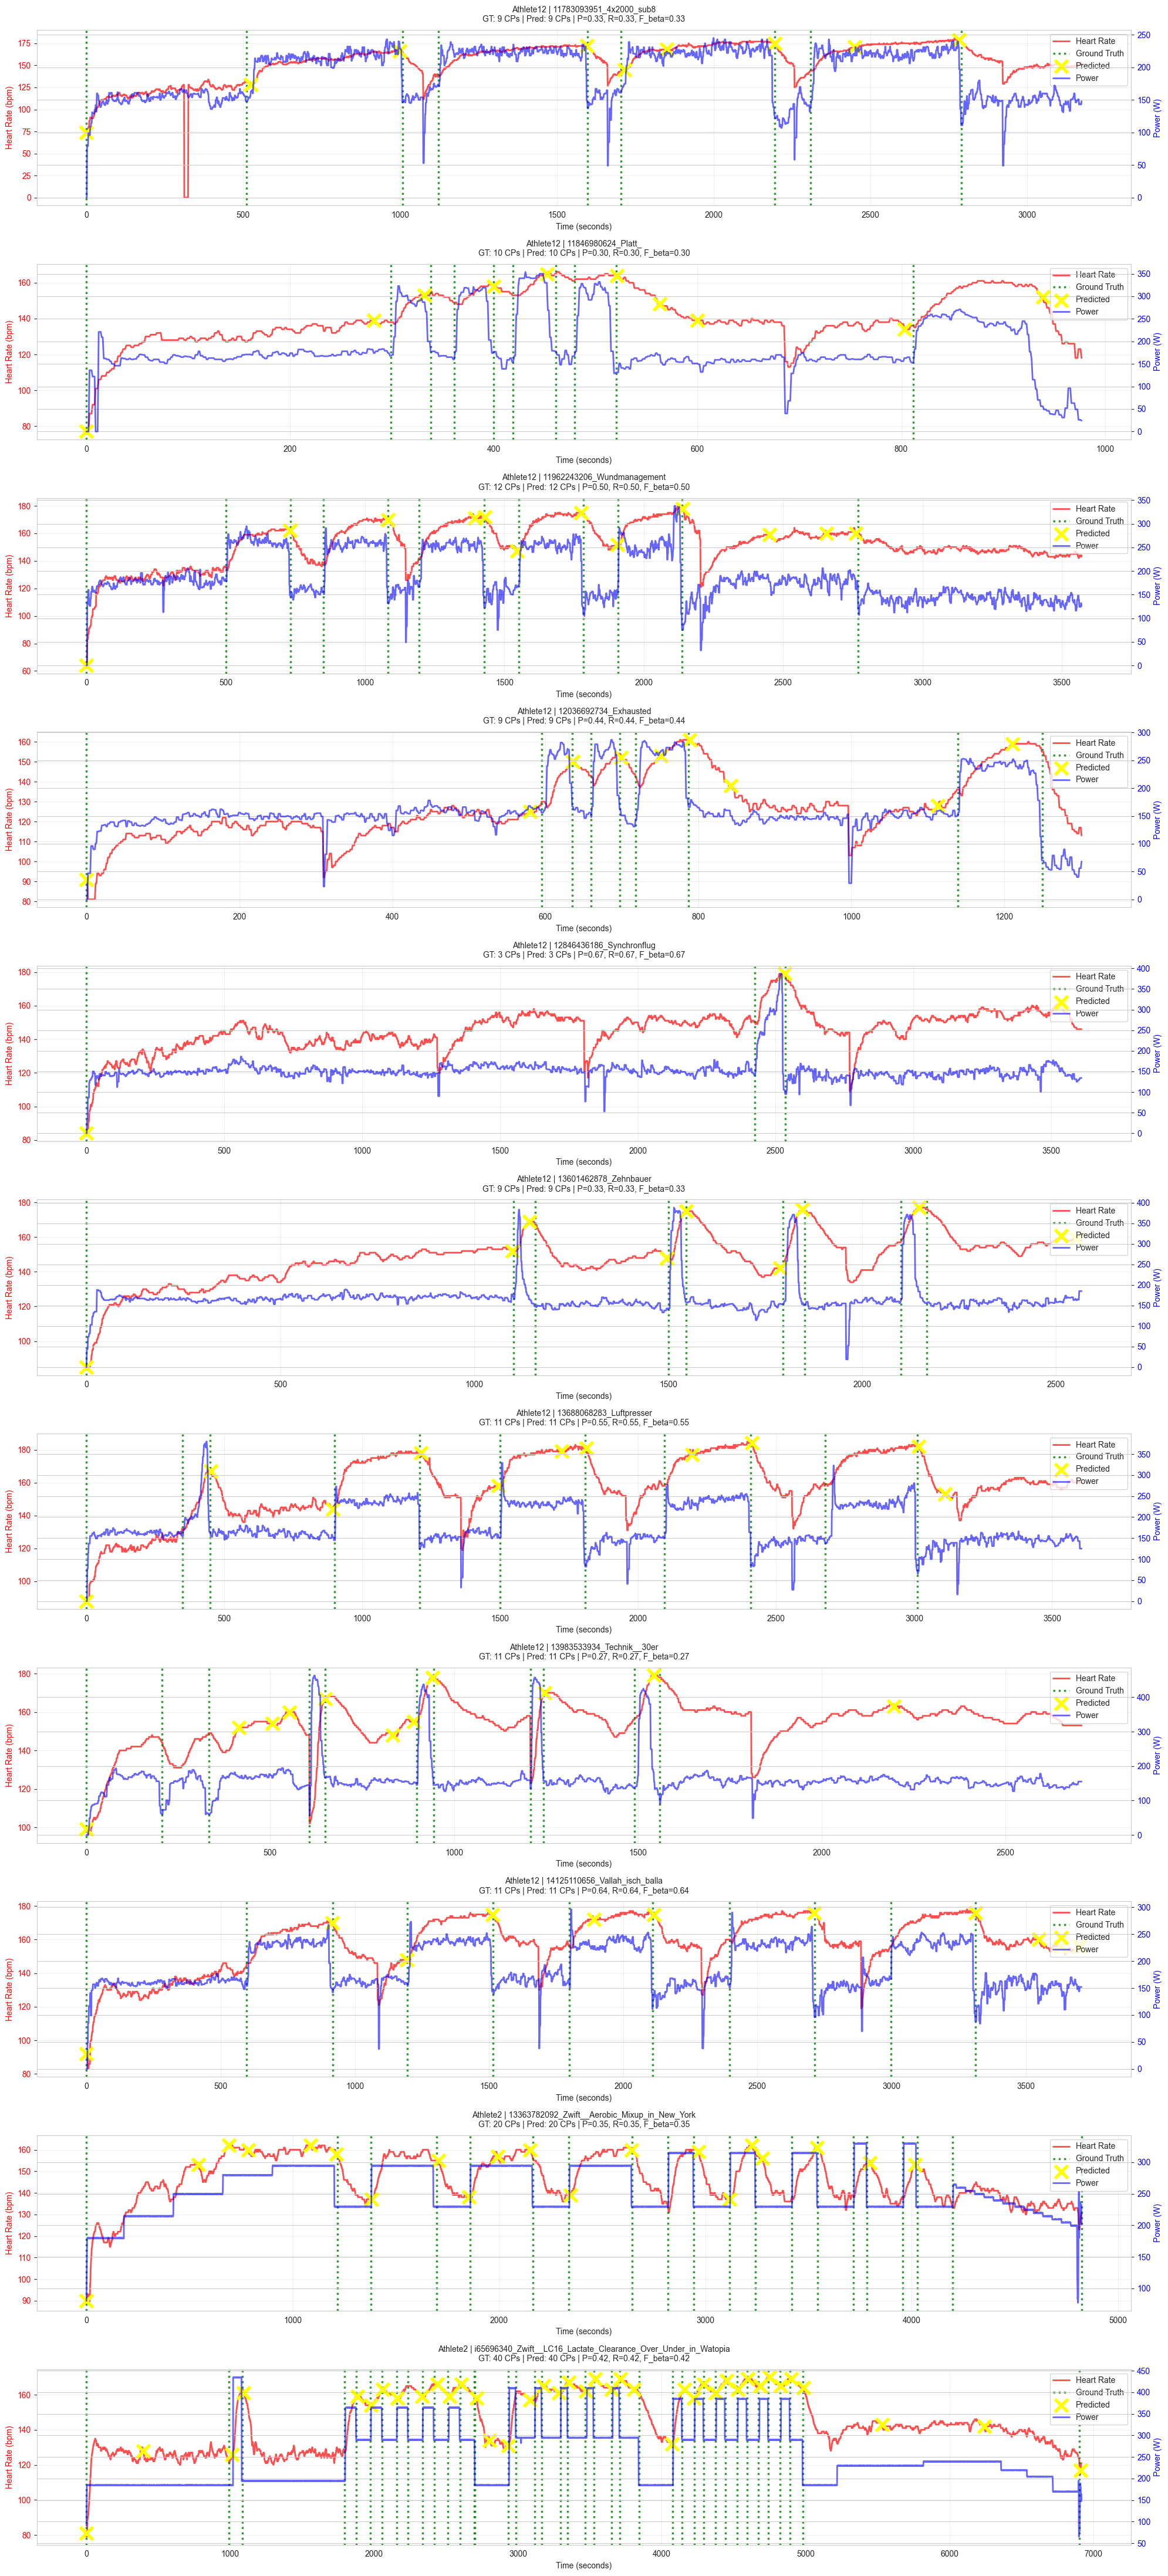

In [11]:
# Create subplots for all test sessions
n_sessions = len(results_mc)  # Changed from results to results_mc
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, result in enumerate(results_mc):  # Changed from results to results_mc
    df = result['df']
    y_true = result['y_true']
    y_pred = result['y_pred']

    hr_values = df['heart_rate'].values

    # Create twin axis for power
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Plot heart rate on left axis (RED)
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power on right axis (BLUE)
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    pred_cps = np.where(y_pred == 1)[0]

    # Mark ground truth change points with GREEN vertical dotted lines
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                       alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark predicted change points with YELLOW X
    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                       linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

    # Set title with session info and metrics
    ax1.set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 10. Save Model

In [12]:
# Save the multi-channel model
model_mc.save('cnn_model_multichannel.keras')

# Save the scaler
import joblib
joblib.dump(scaler, 'cnn_scaler_multichannel.pkl')

# Save results to CSV
pd.DataFrame([{k: r[k] for k in ['athlete', 'session', 'f_beta', 'precision', 'recall', 'mean_error_sec', 'n_true', 'n_pred']}
             for r in results_mc]).to_csv('cnn_results_multichannel.csv', index=False)

print("✓ Saved: cnn_model_multichannel.keras, cnn_scaler_multichannel.pkl, cnn_results_multichannel.csv")

✓ Saved: cnn_model_multichannel.keras, cnn_scaler_multichannel.pkl, cnn_results_multichannel.csv


In [13]:
# ok next steps:
# try the semantic grouping suggested by claude
# and check out the fast.ai thingy from richard